## Digital Finance, Forecasting & Analytics Platform
## Module 4 — Advanced FP&A: Forecast + Budget vs Actuals
### 4.6 ML Revenue Forecast: Revenue-Only Recursive Ensemble

This section (4.6) extends the forecasting architecture of the Digital Finance, Forecasting & Analytics Platform with a **Machine Learning-based revenue forecasting layer**, designed to complement the statistical SARIMA framework developed in Section 4.2.

| Dimension | SARIMA (4.2) | ML Ensemble (4.6) |
|----------|--------------|-------------------|
| **Input** | Revenue time series only | Revenue time series only |
| **Modeling logic** | Statistical temporal autocorrelation | Recursive ML using revenue lags and calendar features |
| **Features** | ARIMA/SARIMA terms, seasonality | month seasonality, stress flag, rev_lag1, rev_lag12, rev_yoy |
| **Forecast method** | Statistical time-series forecast | Ex-ante recursive multi-step forecast |
| **Interpretability** | ACF / PACF structure, SARIMA parameters | Lag sensitivity, calendar effects, model comparison |
| **FP&A value** | Baseline forecast trajectory | ML benchmark under revenue-only assumptions |

Together, **Modules 4.2 and 4.6** form a complete FP&A intelligence engine — statistical time-series governance anchored by driver-based machine learning attribution.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_style('darkgrid')
palette = sns.color_palette('deep')

## 2. Load Dataset

In [3]:
df = pd.read_csv('reg.csv')
df.head()

,datekey,Revenue,Marketing,price_D_A,price_D_E,price_D_I,price_O_A,price_O_E,price_O_I,price_R_A,...,price_R_I,units_D_A,units_D_E,units_D_I,units_O_A,units_O_E,units_O_I,units_R_A,units_R_E,units_R_I
0,201001,954.07,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,265.0,7.0,147.0,14.0,12.0,3.0,309.0,151.0,53.0
1,201002,1033.57,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,287.0,7.0,159.0,16.0,13.0,4.0,335.0,164.0,58.0
2,201003,1351.59,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,375.0,9.0,208.0,20.0,17.0,5.0,438.0,214.0,76.0
3,201004,1272.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,353.0,9.0,196.0,19.0,16.0,4.0,412.0,202.0,71.0
4,201005,1431.08,48.92,591.6,1224.0,1616.0,650.76,1248.48,1696.8,709.92,...,1858.4,397.0,10.0,220.0,22.0,18.0,5.0,463.0,227.0,80.0


## 3. Feature Engineering

The revenue-only ML design uses only information that is legitimate in an ex-ante forecast setting:

- `month_sin`, `month_cos`: deterministic calendar seasonality
- `is_stress`: structural regime flag for 2018-2019
- `rev_lag1`: previous month revenue
- `rev_lag12`: same month previous year revenue
- `rev_yoy`: year-over-year growth known as of the previous month

The key methodological distinction versus Module 4.6 is that these lagged revenue features are used **recursively** in the forecast horizon rather than read directly from realized future values.

In [4]:
# Calendar features
df['year'] = df['datekey'].astype(str).str[:4].astype(int)
df['month'] = df['datekey'].astype(str).str[4:6].astype(int)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Structural break flag
df['is_stress'] = ((df['year'] >= 2018) & (df['year'] <= 2019)).astype(int)

# Revenue lag features for training sample
df['rev_lag1'] = df['Revenue'].shift(1)
df['rev_lag12'] = df['Revenue'].shift(12)
df['rev_yoy'] = df['Revenue'].pct_change(12).shift(1)

df_ml = df.dropna().reset_index(drop=True)

feature_cols = ['month_sin', 'month_cos', 'is_stress', 'rev_lag1', 'rev_lag12', 'rev_yoy']

print(f'Dataset: {df_ml.shape[0]} observations | {df_ml.shape[1]} columns')
df_ml[['datekey', 'Revenue', 'month_sin', 'month_cos', 'is_stress', 'rev_lag1', 'rev_lag12', 'rev_yoy']].head()

Dataset: 167 observations | 29 columns


,datekey,Revenue,month_sin,month_cos,is_stress,rev_lag1,rev_lag12,rev_yoy
0,201102,1315.96,8.660254e-01,5.000000e-01,0,990.18,1033.57,0.037848
1,201103,1156.89,1.000000e+00,6.123234e-17,0,1315.96,1351.59,0.273218
2,201104,1551.60,8.660254e-01,-5.000000e-01,0,1156.89,1272.08,-0.144053
3,201105,1822.10,5.000000e-01,-8.660254e-01,0,1551.60,1431.08,0.219735
4,201106,1438.47,1.224647e-16,-1.000000e+00,0,1822.10,1510.61,0.273234


## 4. Train / Test Split

The training sample ends in **December 2022**, and the forecast horizon covers **January 2023 to December 2024**. The split itself is chronological and standard. The crucial methodological step comes next: the test horizon is forecast **recursively**, so future lagged revenue inputs are generated from prior predictions rather than from realized future values.

In [5]:
train_mask = df_ml['year'] <= 2022
test_mask = df_ml['year'] >= 2023

X_train = df_ml.loc[train_mask, feature_cols]
y_train = df_ml.loc[train_mask, 'Revenue']

test_dates = df_ml.loc[test_mask, ['datekey', 'year', 'month', 'month_sin', 'month_cos', 'is_stress']].reset_index(drop=True)
y_test = df_ml.loc[test_mask, 'Revenue'].reset_index(drop=True)

print(f'Train: {len(X_train)} obs ({df_ml.loc[train_mask, "datekey"].iloc[0]} -> {df_ml.loc[train_mask, "datekey"].iloc[-1]})')
print(f'Test:  {len(test_dates)} obs ({test_dates["datekey"].iloc[0]} -> {test_dates["datekey"].iloc[-1]})')

Train: 143 obs (201102 -> 202212)
Test:  24 obs (202301 -> 202412)


## 5. Recursive Forecast Engine

This function converts one-step ML models into valid **multi-step ex-ante forecasts**. For each future month:

1. `rev_lag1` uses the most recent available revenue value
2. `rev_lag12` uses the value from 12 months earlier
3. `rev_yoy` is computed from those lagged values
4. once the horizon moves beyond 12 months, prior forecasts begin to feed later lags

This mirrors how autoregressive statistical models propagate their own prior predictions through the forecast horizon.

In [6]:
def recursive_forecast(model, history_df, future_calendar_df, feature_cols):
    history_values = history_df[['datekey', 'Revenue']].copy().reset_index(drop=True)
    preds = []

    for _, cal_row in future_calendar_df.iterrows():
        revenue_history = history_values['Revenue'].tolist() + preds

        rev_lag1 = revenue_history[-1]
        rev_lag12 = revenue_history[-12]
        rev_yoy = (revenue_history[-1] / revenue_history[-13]) - 1

        row = {
            'month_sin': cal_row['month_sin'],
            'month_cos': cal_row['month_cos'],
            'is_stress': cal_row['is_stress'],
            'rev_lag1': rev_lag1,
            'rev_lag12': rev_lag12,
            'rev_yoy': rev_yoy,
        }

        X_row = pd.DataFrame([row])[feature_cols]
        y_hat = model.predict(X_row)[0]
        preds.append(y_hat)

    result = future_calendar_df[['datekey']].copy()
    result['Forecast'] = preds
    return result

## 6. ML Models

Three tree-based regressors are trained on the historical sample. They are then deployed through the same recursive engine so that all models face the identical 24-month ex-ante forecasting problem.

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42
)

lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

xgb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train);

In [8]:
history_df = df_ml.loc[train_mask, ['datekey', 'Revenue']].copy().reset_index(drop=True)

xgb_fc = recursive_forecast(xgb_model, history_df, test_dates, feature_cols)
rf_fc = recursive_forecast(rf_model, history_df, test_dates, feature_cols)
lgb_fc = recursive_forecast(lgb_model, history_df, test_dates, feature_cols)

y_pred_xgb = xgb_fc['Forecast'].values
y_pred_rf = rf_fc['Forecast'].values
y_pred_lgb = lgb_fc['Forecast'].values
y_pred_ensemble = (y_pred_xgb + y_pred_rf + y_pred_lgb) / 3

In [9]:
def compute_metrics(y_true, y_pred):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    wape = np.sum(np.abs(np.array(y_true) - np.array(y_pred))) / np.sum(np.abs(np.array(y_true))) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mape, wape, rmse

mape_xgb, wape_xgb, rmse_xgb = compute_metrics(y_test, y_pred_xgb)
mape_rf, wape_rf, rmse_rf = compute_metrics(y_test, y_pred_rf)
mape_lgb, wape_lgb, rmse_lgb = compute_metrics(y_test, y_pred_lgb)
mape_ens, wape_ens, rmse_ens = compute_metrics(y_test, y_pred_ensemble)

print(f'XGBoost      MAPE: {mape_xgb:.2f}%  |  WAPE: {wape_xgb:.2f}%  |  RMSE: {rmse_xgb:.2f}')
print(f'RandomForest MAPE: {mape_rf:.2f}%  |  WAPE: {wape_rf:.2f}%  |  RMSE: {rmse_rf:.2f}')
print(f'LightGBM     MAPE: {mape_lgb:.2f}%  |  WAPE: {wape_lgb:.2f}%  |  RMSE: {rmse_lgb:.2f}')
print(f'ML Ensemble  MAPE: {mape_ens:.2f}%  |  WAPE: {wape_ens:.2f}%  |  RMSE: {rmse_ens:.2f}')

XGBoost      MAPE: 15.82%  |  WAPE: 16.20%  |  RMSE: 542.42
RandomForest MAPE: 15.95%  |  WAPE: 16.25%  |  RMSE: 550.20
LightGBM     MAPE: 15.74%  |  WAPE: 16.37%  |  RMSE: 534.94
ML Ensemble  MAPE: 15.20%  |  WAPE: 15.77%  |  RMSE: 532.95


## 7. Forecast Output Table

In [10]:
ml_df = test_dates[['datekey']].copy()
ml_df['Revenue'] = y_test.values
ml_df['year'] = ml_df['datekey'].astype(str).str[:4].astype(int)
ml_df['XGBoost'] = np.round(y_pred_xgb, 2)
ml_df['RandomForest'] = np.round(y_pred_rf, 2)
ml_df['LightGBM'] = np.round(y_pred_lgb, 2)
ml_df['Ensemble'] = np.round(y_pred_ensemble, 2)
ml_df['Diff'] = np.round(ml_df['Revenue'] - ml_df['Ensemble'], 2)
ml_df.head()

,datekey,Revenue,year,XGBoost,RandomForest,LightGBM,Ensemble,Diff
0,202301,2120.17,2023,2215.020020,2121.40,2046.69,2127.70,-7.53
1,202302,1817.49,2023,1931.859985,1897.58,1942.05,1923.83,-106.34
2,202303,2455.10,2023,2263.129883,2164.68,2192.84,2206.89,248.21
3,202304,2507.32,2023,2391.340088,2396.53,2563.99,2450.62,56.70
4,202305,2820.73,2023,2571.379883,2439.98,2378.15,2463.17,357.56


## 8. SARIMA Benchmark

The SARIMA Dual-Memory benchmark is loaded from the baseline output file and evaluated on the same 2023-2024 horizon. Only the `final_23_forecast.csv` file is required, since it already contains the full 24-month horizon.

In [11]:
fc_23 = pd.read_csv('forecast_output/final_23_forecast.csv')

sarima_ref = fc_23[['Date', 'Revenue', 'Final_Forecast']].copy()
sarima_ref.columns = ['datekey', 'Revenue_sarima', 'SARIMA']
sarima_ref = sarima_ref[(sarima_ref['datekey'] >= 202301) & (sarima_ref['datekey'] <= 202412)].reset_index(drop=True)

mape_sarima, wape_sarima, rmse_sarima = compute_metrics(sarima_ref['Revenue_sarima'], sarima_ref['SARIMA'])
print(f'SARIMA Dual-Memory  MAPE: {mape_sarima:.2f}%  |  WAPE: {wape_sarima:.2f}%  |  RMSE: {rmse_sarima:.2f}')

SARIMA Dual-Memory  MAPE: 12.06%  |  WAPE: 11.44%  |  RMSE: 353.96


In [12]:
metrics = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'LightGBM', 'ML Ensemble', 'SARIMA Dual-Memory'],
    'MAPE (%)': [round(mape_xgb, 2), round(mape_rf, 2), round(mape_lgb, 2), round(mape_ens, 2), round(mape_sarima, 2)],
    'WAPE (%)': [round(wape_xgb, 2), round(wape_rf, 2), round(wape_lgb, 2), round(wape_ens, 2), round(wape_sarima, 2)],
    'RMSE': [round(rmse_xgb, 2), round(rmse_rf, 2), round(rmse_lgb, 2), round(rmse_ens, 2), round(rmse_sarima, 2)]
})
metrics

,Model,MAPE (%),WAPE (%),RMSE
0,XGBoost,15.82,16.20,542.42
1,Random Forest,15.95,16.25,550.20
2,LightGBM,15.74,16.37,534.94
3,ML Ensemble,15.20,15.77,532.95
4,SARIMA Dual-Memory,12.06,11.44,353.96


## 9. Forecast Comparison Plot

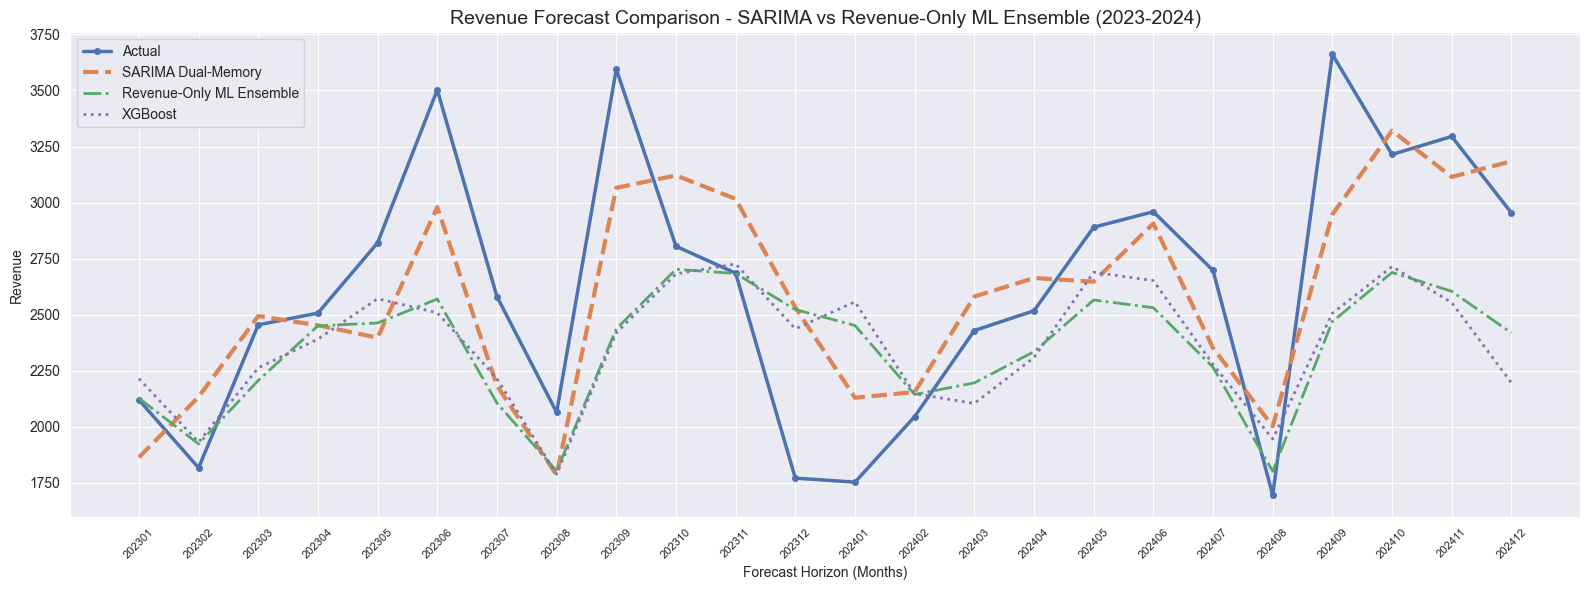

In [13]:
compare_df = ml_df.merge(sarima_ref[['datekey', 'SARIMA']], on='datekey', how='left')

plt.figure(figsize=(16, 6))
plt.plot(compare_df.index, compare_df['Revenue'], label='Actual', linewidth=2.5, marker='o', markersize=4, color=palette[0])
plt.plot(compare_df.index, compare_df['SARIMA'], label='SARIMA Dual-Memory', linewidth=3, linestyle='--', color=palette[1])
plt.plot(compare_df.index, compare_df['Ensemble'], label='Revenue-Only ML Ensemble', linewidth=2, linestyle='-.', color=palette[2])
plt.plot(compare_df.index, compare_df['XGBoost'], label='XGBoost', linewidth=2, linestyle=':', color=palette[4])
plt.title('Revenue Forecast Comparison - SARIMA vs Revenue-Only ML Ensemble (2023-2024)', fontsize=14)
plt.xlabel('Forecast Horizon (Months)')
plt.ylabel('Revenue')
plt.xticks(compare_df.index, compare_df['datekey'].astype(str), rotation=45, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()